In [5]:
import os
import warnings
warnings.filterwarnings("ignore", message="IProgress not found")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import VarianceThreshold, RFE
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from sklearn.inspection import permutation_importance

from catboost import CatBoostRegressor
import optuna
from optuna.samplers import TPESampler

from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge

print("Все библиотеки успешно импортированы")

Все библиотеки успешно импортированы


In [6]:
df = pd.read_csv('../data/processed/dataset_for_ml.csv', dtype={'Fingerprint_1024b': str})

X_fp = np.array([[int(bit) for bit in fp] for fp in df['Fingerprint_1024b']])
X_props = df.iloc[:, 3:].values
X = np.column_stack((X_fp, X_props))
y = df['Binding_Affinity_kcal_mol'].values

print("Финальный размер матрицы X (признаки):", X.shape)
print("Финальный размер вектора y (ответы):", y.shape)

Финальный размер матрицы X (признаки): (1196, 1039)
Финальный размер вектора y (ответы): (1196,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

selector = VarianceThreshold(threshold=(.95 * (1 - .95)))
X_train_vt = selector.fit_transform(X_train)
X_test_vt = selector.transform(X_test)
print("Исходное количество признаков:", X_train.shape[1])
print("Осталось признаков после VarianceThreshold:", X_train_vt.shape[1])

base_estimator = RandomForestRegressor(n_estimators=200, max_depth= 10, random_state=42, n_jobs=-1)
selector_rfe = RFE(estimator= base_estimator, n_features_to_select= 120, step= 1, verbose= 0)
X_train_final = selector_rfe.fit_transform(X_train_vt, y_train)
X_test_final = selector_rfe.transform(X_test_vt)
print("Осталось признаков после RFE очистки:", X_train_final.shape[1])
print(f"\nРазмерность финального трейна: {X_train_final.shape}")
print(f"Размерность финального теста: {X_test_final.shape}")

Исходное количество признаков: 1039
Осталось признаков после VarianceThreshold: 262
Осталось признаков после RFE очистки: 120

Размерность финального трейна: (956, 120)
Размерность финального теста: (240, 120)


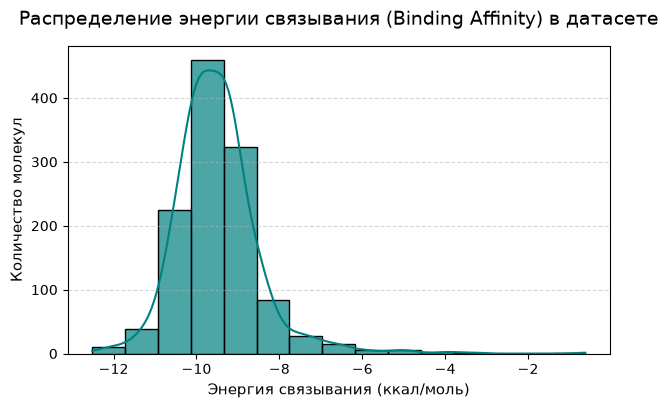

--- БАЗОВАЯ СТАТИСТИКА ДАТАСЕТА ---
Минимальная энергия (лучшее связывание): -12.514 ккал/моль
Максимальная энергия (худшее связывание): -0.615 ккал/моль
Среднее значение энергии (Mean):         -9.50 ккал/моль
Медианное значение энергии (Median):     -9.57 ккал/моль
Стандартное отклонение (Std Dev):        1.03 ккал/моль


In [8]:
plt.figure(figsize=(7,4))

sns.histplot(y, kde=True, color='teal', bins=15, edgecolor = 'black', alpha = 0.7)
plt.title('Распределение энергии связывания (Binding Affinity) в датасете', fontsize=14, pad=15)
plt.xlabel('Энергия связывания (ккал/моль)', fontsize=11)
plt.ylabel('Количество молекул', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

print("--- БАЗОВАЯ СТАТИСТИКА ДАТАСЕТА ---")
print(f"Минимальная энергия (лучшее связывание): {y.min()} ккал/моль")
print(f"Максимальная энергия (худшее связывание): {y.max()} ккал/моль")
print(f"Среднее значение энергии (Mean):         {y.mean():.2f} ккал/моль")
print(f"Медианное значение энергии (Median):     {np.median(y):.2f} ккал/моль")
print(f"Стандартное отклонение (Std Dev):        {y.std():.2f} ккал/моль")

In [9]:
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 600),
        'max_depth': trial.suggest_int('max_depth', 8, 25),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 4),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'random_state': 42,
        'n_jobs': -1 
    }

    kf = KFold(n_splits= 5, shuffle= True, random_state= 42)
    scores = []

    for train_idx, val_idx in kf.split(X_train_final):
        X_tr, X_val = X_train_final[train_idx], X_train_final[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        model = RandomForestRegressor(**params)
        model.fit(X_tr, y_tr)

        preds = model.predict(X_val)
        scores.append(mean_absolute_error(y_val, preds))

    return np.mean(scores)

optuna.logging.set_verbosity(optuna.logging.WARNING)
study_rf = optuna.create_study(direction='minimize', sampler= TPESampler(seed= 42))
study_rf.optimize(objective_rf, n_trials=50)

print(f'\nЛучшие параметры для Random Forest: {study_rf.best_params}')
print(f'Лучший показатель MAE на кросс-валидации: {study_rf.best_value:.4f}')

best_params_rf = study_rf.best_params
best_params_rf['random_state'] = 42
best_params_rf['n_jobs'] = -1

final_model_rf = RandomForestRegressor(**best_params_rf)


Лучшие параметры для Random Forest: {'n_estimators': 462, 'max_depth': 24, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
Лучший показатель MAE на кросс-валидации: 0.4622



Метрики RandomForest
Абсолютная ошибка (MAE):           0.450 ккал/моль
Квадратичная ошибка (RMSE):           0.625 ккал/моль
Коэффициент детерминации (R2 Score):           0.458


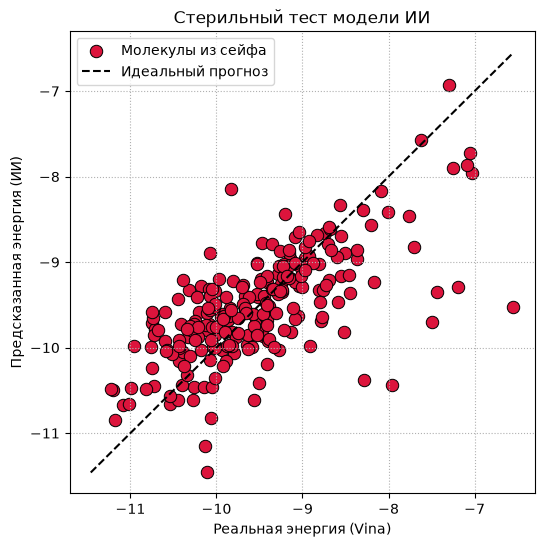

In [10]:
final_model_rf.fit(X_train_final, y_train)

y_pred_rf = final_model_rf.predict(X_test_final)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print('\nМетрики RandomForest')
print(f"Абсолютная ошибка (MAE):           {mae_rf:.3f} ккал/моль")
print(f"Квадратичная ошибка (RMSE):           {rmse_rf:.3f} ккал/моль")
print(f"Коэффициент детерминации (R2 Score):           {r2_rf:.3f}")

plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred_rf, color='crimson', edgecolor='black', s=80, label='Молекулы из сейфа')
low_bound = min(np.min(y_test), np.min(y_pred_rf))
high_bound = max(np.max(y_test), np.max(y_pred_rf))
lims = [low_bound, high_bound]
plt.plot(lims, lims, color='black', linestyle='--', label='Идеальный прогноз')
plt.title('Стерильный тест модели ИИ')
plt.xlabel('Реальная энергия (Vina)')
plt.ylabel('Предсказанная энергия (ИИ)')
plt.grid(True, linestyle=':')
plt.legend()
plt.show()

In [11]:
all_property_cols = list(df.columns[3:])
feature_names_full = all_property_cols + [f'Morgan_Bit_{i}' for i in range(1024)] 
support_mask = selector_rfe.get_support()
feature_names = [name for name, selected in zip(feature_names_full, support_mask) if selected]

result = permutation_importance(final_model_rf, X_test_final, y_test, n_repeats=10, random_state=42)

perm_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=False)

print(perm_importances.head(15))


            Feature  Importance
107  Morgan_Bit_232    0.060224
112  Morgan_Bit_237    0.038521
108  Morgan_Bit_233    0.029031
109  Morgan_Bit_234    0.015853
25    Morgan_Bit_46    0.006907
17    Morgan_Bit_22    0.006649
1              LogP    0.006125
10     Morgan_Bit_2    0.005248
115  Morgan_Bit_240    0.005239
53   Morgan_Bit_110    0.005096
100  Morgan_Bit_215    0.004961
26    Morgan_Bit_53    0.004287
80   Morgan_Bit_182    0.003489
39    Morgan_Bit_76    0.003416
46    Morgan_Bit_90    0.003390


In [12]:
def objective_cat(trial):
    params = {
        'iterations': 1000,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15),
        'depth': trial.suggest_int('depth', 4, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'loss_function': 'MAE',
        'eval_metric': 'MAE',
        'random_state': 42,
        'logging_level': 'Silent'
    }
    
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    
    for train_idx, val_idx in kf.split(X_train_final):
        X_tr, X_va = X_train_final[train_idx], X_train_final[val_idx]
        y_tr, y_va = y_train[train_idx], y_train[val_idx]
        
        model = CatBoostRegressor(**params)
        model.fit(X_tr, y_tr) 
        
        preds = model.predict(X_va)
        scores.append(mean_absolute_error(y_va, preds))
        
    return np.mean(scores)

optuna.logging.set_verbosity(optuna.logging.WARNING)
study_cat = optuna.create_study(direction='minimize', sampler= TPESampler(seed= 42))
study_cat.optimize(objective_cat, n_trials= 30)

best_params_cat = study_cat.best_params
print(f"\nЛучшие параметры от Optuna: {best_params_cat}")
print("Лучший результат (MAE):", study_cat.best_value)

best_params_cat['iterations'] = 1000
best_params_cat['loss_function'] = 'MAE'
best_params_cat['eval_metric'] = 'MAE'
best_params_cat['random_state'] = 42
best_params_cat['logging_level'] = 'Silent'

final_model_cat = CatBoostRegressor(**best_params_cat)    


Лучшие параметры от Optuna: {'learning_rate': 0.03373402622882698, 'depth': 6, 'l2_leaf_reg': 2.5114861602739396}
Лучший результат (MAE): 0.45802441937781974


In [13]:
final_model_cat.fit(X_train_final, y_train)

y_pred_cat = final_model_cat.predict(X_test_final)
mae_cat = mean_absolute_error(y_test, y_pred_cat)
rmse_cat = np.sqrt(mean_squared_error(y_test, y_pred_cat))
r2_cat = r2_score(y_test, y_pred_cat)

print('\nМетрики CatBoost')
print(f"Абсолютная ошибка (MAE):           {mae_cat:.3f} ккал/моль")
print(f"Квадратичная ошибка (RMSE):        {rmse_cat:.3f} ккал/моль")
print(f"Коэффициент детерминации (R2):    {r2_cat:.3f}")


Метрики CatBoost
Абсолютная ошибка (MAE):           0.442 ккал/моль
Квадратичная ошибка (RMSE):        0.632 ккал/моль
Коэффициент детерминации (R2):    0.445


In [14]:
print("Расчет финальных предсказаний для ансамбля...")

base_models = [
    ('rf', RandomForestRegressor(**best_params_rf)),
    ('cb', CatBoostRegressor(**best_params_cat))
]

stacking_ensemble = StackingRegressor(estimators= base_models, final_estimator= Ridge(), cv = 5, n_jobs = -1)
stacking_ensemble.fit(X_train_final, y_train)

y_pred_stack = stacking_ensemble.predict(X_test_final)

mae_stack = mean_absolute_error(y_test, y_pred_stack)
rmse_stack = np.sqrt(mean_squared_error(y_test, y_pred_stack))
r2_stack = r2_score(y_test, y_pred_stack)

print('Метрики ансамбля')
print(f"   Абсолютная ошибка (MAE):           {mae_stack:.3f} ккал/моль")
print(f"   Квадратичная ошибка (RMSE):        {rmse_stack:.3f} ккал/моль")
print(f"   Коэффициент детерминации (R2):    {r2_stack:.3f}")

Расчет финальных предсказаний для ансамбля...
Метрики ансамбля
   Абсолютная ошибка (MAE):           0.457 ккал/моль
   Квадратичная ошибка (RMSE):        0.638 ккал/моль
   Коэффициент детерминации (R2):    0.434


In [16]:
import joblib

MODEL_DIR = "../models"

joblib.dump(final_model_rf, os.path.join(MODEL_DIR, 'hiv_protease_model.pkl'))

joblib.dump(selector, os.path.join(MODEL_DIR, '1_variance_selector.pkl'))

joblib.dump(selector_rfe, os.path.join(MODEL_DIR, '2_rfe_selector.pkl'))

print("Конвейер полностью сохранен! Создано 3 файла.")

Конвейер полностью сохранен! Создано 3 файла.
